## `Part 1: Load and Understand the Data`

In [1]:
# imports pandas library and assigns it alias 'pd'
import pandas as pd 

In [2]:
# imports the 'data' function from the pydataset library
from pydataset import data 

#### `1. import the dataset into a Pandas DataFrame`

In [3]:
# Loads mtcars dataset and assigns it in DataFrame variable 'df'. 
df = data('mtcars') 

#### `2. display the first 5 rows`

In [4]:
df.head() # head() function shows first 5 rows of DataFrame 'df' by default

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


#### `3a. shape of the dataset`

In [5]:
df.shape # Returns a tuple containing 32 rows and 11 columns in the DataFrame

(32, 11)

#### `3b. column names`

In [6]:
df.columns # displays all the column headers in the DataFrame

Index(['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb'],
      dtype='str')

#### `3c. data types`

In [7]:
df.dtypes # will display a Series object with the column names as the index and their corresponding data types as values.

mpg     float64
cyl       int64
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs        int64
am        int64
gear      int64
carb      int64
dtype: object

#### `3d. summary statistics`

In [8]:
df.describe() # optional parameter include='all' can be added to generate statistics for non-numeric columns as well

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


#### `4. checking of missing values` 

In [9]:
df.isnull().sum().sum() # no missing values in DataFrame df

np.int64(0)

## `Part 2: Basic Data Analysis`

#### `5a. average milage(mpg)`

In [10]:
average_mpg = df['mpg'].mean()
print('average milage(mpg): {:.2f}'.format(average_mpg))

average milage(mpg): 20.09


#### `5b. maximum horsepower(hp)`

In [11]:
max_hp = df['hp'].max()
print('maximum horsepower(hp): {}'.format(max_hp))

maximum horsepower(hp): 335


#### `5c.minimum and maximum Weight(wt)`

In [12]:
min_wt = df['wt'].min()
max_wt = df['wt'].max()
print('minimum weight(wt): %.2f' % min_wt)
print(f'maximum weight(wt): {max_wt:.2f}')

minimum weight(wt): 1.51
maximum weight(wt): 5.42


#### `6. count of cars(cylinder wise)`

In [13]:
df.cyl.value_counts() # number of cars per cylinder in the dataFrame 

cyl
8    14
4    11
6     7
Name: count, dtype: int64

#### `7. average milage of each cylinder category(using groupby)`

In [14]:
df.groupby('cyl')['mpg'].mean() # group by cylinder and calculate mean mpg

cyl
4    26.663636
6    19.742857
8    15.100000
Name: mpg, dtype: float64

## `Part 3: Intermediate Analysis`

#### 8a. compare average milage(by transmission type: column am)

In [15]:
df.groupby('am')['mpg'].mean() # calculate average mileage by transmission type

am
0    17.147368
1    24.392308
Name: mpg, dtype: float64

#### `8b. compare average milage(by number of gears: column gear)`

In [16]:
df.groupby('gear')['mpg'].mean() # calculate average mileage by number of gears 

gear
3    16.106667
4    24.533333
5    21.380000
Name: mpg, dtype: float64

#### `9. pivot table showing average mpg by cyl and am`

In [17]:
df.pivot_table(values='mpg', index='am', columns='cyl', aggfunc='mean')

cyl,4,6,8
am,,,
0,22.900,19.125000,15.05
1,28.075,20.566667,15.40


#### `10. create column'efficiency' where cars with mpg > 20 are "High" and others "Low"`

In [18]:
df['efficiency'] = df['mpg'].apply(lambda x: "High" if x > 20 else "Low")
df[['mpg', 'efficiency']].head()  # Use double square brackets to select multiple columns

,mpg,efficiency
Mazda RX4,21.0,High
Mazda RX4 Wag,21.0,High
Datsun 710,22.8,High
Hornet 4 Drive,21.4,High
Hornet Sportabout,18.7,Low


#### `11. map() to convert -> am: 0 = Automatic, 1 = Manual and vs: 0 = V-shaped, 1 = Straight`

In [19]:
# encode - map
df['am'] = df['am'].map({0: 'Automatic', 1: 'Manual'})
df['vs'] = df['vs'].map({0: 'V-shaped', 1: 'Straight'})
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,efficiency
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,V-shaped,Manual,4,4,High
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,V-shaped,Manual,4,4,High
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,Straight,Manual,4,1,High
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,Straight,Automatic,3,1,High
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,V-shaped,Automatic,3,2,Low


## `Part 4: Data Visualization`

#### `12a. bar chart of avg mpg per cylinders`

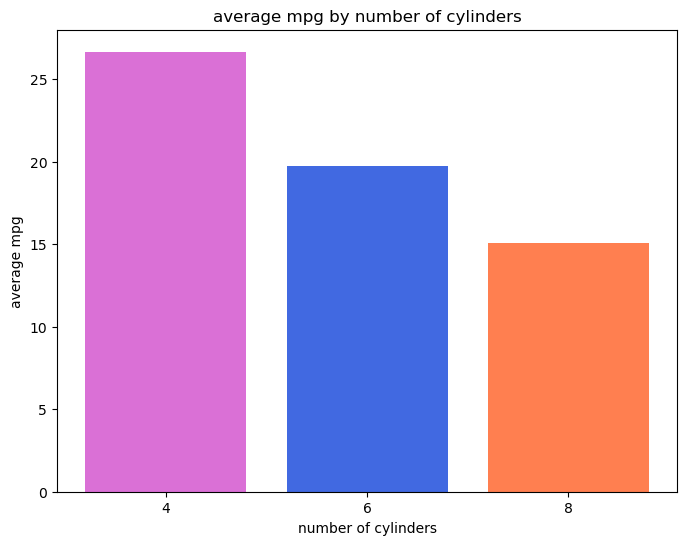

In [20]:
import matplotlib.pyplot as plt

# Group data by cylinders and calculate the mean of miles per gallon
avg_mpg_by_cyl = df.groupby('cyl')['mpg'].mean().reset_index()

# Initialize plot dimensions (width=8, height=6)
plt.figure(figsize=(8, 6))

# Define a list of colors for the individual bars
my_colors = ['orchid', 'royalblue', 'coral']

# Create the bar chart
# Converting 'cyl' to string ensures Matplotlib treats them as distinct labels
plt.bar(avg_mpg_by_cyl['cyl'].astype(str), avg_mpg_by_cyl['mpg'], color=my_colors)

# Label the axes and provide a clear chart title
plt.xlabel('number of cylinders')
plt.ylabel('average mpg')
plt.title('average mpg by number of cylinders')

# Render the final plot
plt.show()


##### 12a. Observations:
- Cylinder count and Fuel efficiency have inverse relationship between them. As the number of cylinders increases, the   
average mpg decreases dramatically.
- 4 cylinder cars are most fuel efficient(average 26.6 mpg) . 8 cylinders are least fuel efficient(average 15.1 mpg) 

#### `12b. scatter plot of wt vs mpg`

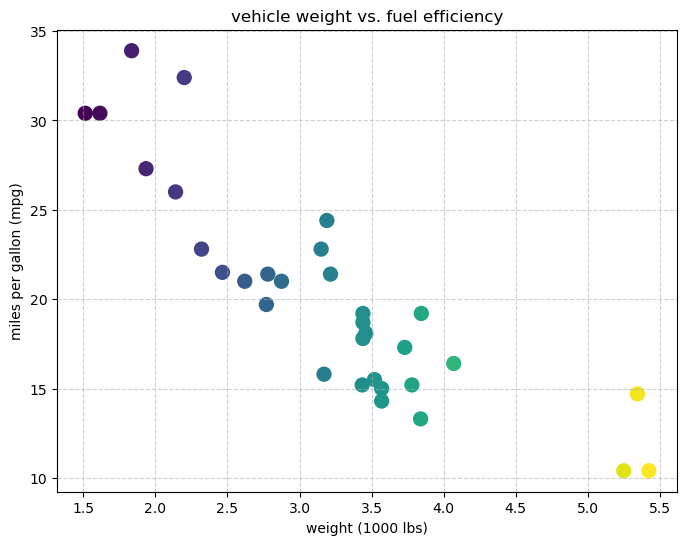

In [21]:
import matplotlib.pyplot as plt

# Create the figure with a size of 8x6 inches
plt.figure(figsize=(8, 6))

# 'c=df['wt']' assigns color based on weight, 'cmap' sets the color theme
# 's=100' sets the size of the points
plt.scatter(df['wt'], df['mpg'], c=df['wt'], cmap='viridis', s=100)

# Add titles and axis labels
plt.title('vehicle weight vs. fuel efficiency')
plt.xlabel('weight (1000 lbs)')
plt.ylabel('miles per gallon (mpg)')

# Add a grid with dashed lines at 60% opacity for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()


##### 12b. Observations:
- Weight and fuel efficiency have inverse relatopnship; as the vehicle weight increases (moving right on the x-axis), the miles per gallon (mpg) consistently decreases (moving down on the y-axis).
- There is a significant efficiency advantage for lighter vehicles, as those weighing roughly 2,000–3,000 lbs achieve much higher mpg compared to heavy vehicles in the 5,000+ lbs range, which cluster at the lowest mpg levels.

#### `12c. histogram of horsepower`

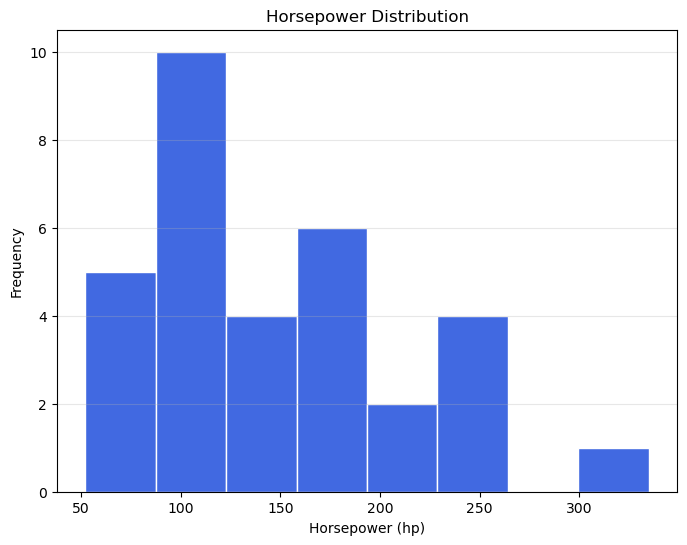

In [22]:
import matplotlib.pyplot as plt

# Set up the figure size
plt.figure(figsize=(8, 6))

# Create histogram using a smaller bin size (bins=8) for a broader view
# A lower bin count groups the data into wider ranges
plt.hist(
    df['hp'], 
    bins=8, 
    color='royalblue', 
    edgecolor='white'
)

# Add descriptive title and axis labels
plt.title('Horsepower Distribution', fontsize=12)
plt.xlabel('Horsepower (hp)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)

# Add subtle horizontal grid lines
plt.grid(axis='y', alpha=0.3)

# Display the plot
plt.show()


##### 12c. Observations:
- The graph is right-skewed (positively skewed), as indicated by a "long tail" stretching toward the higher horsepower values on the right.
- The 100–200 hp category is the most frequent (the mode), containing more vehicles than any other horsepower bracket.
- There is a significant "step-down" in frequency after 200 hp, where the number of vehicles in each subsequent bin drops sharply, confirming that high-performance engines (above 200 hp) are relatively rare in this dataset.


#### `12d. boxplot of mpg by transmission`

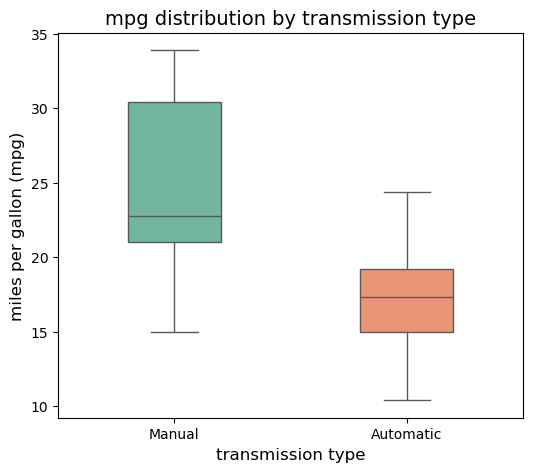

In [23]:
import seaborn as sns
# Create the boxplot with a specified figure size
plt.figure(figsize=(6, 5))
# Create a boxplot using seaborn, showing mpg distribution by transmission type (am)
# 'am' is on x-axis, 'mpg' on y-axis, using Set2 color palette and transmission type for coloring
sns.boxplot(x='am', y='mpg', data=df, palette='Set2', hue='am', legend=False, width = 0.4)

# Add title and labels with custom font sizes
plt.title('mpg distribution by transmission type', fontsize=14)
plt.xlabel('transmission type', fontsize=12)
plt.ylabel('miles per gallon (mpg)', fontsize=12)

# Display the plot
plt.show()

##### 12d. Observations:
- Cars with manual transmissions (am=1) generally achieve significantly better fuel economy than automatic ones. The median MPG for manual cars is approximately 22.15, compared to a much lower median of 16.85 for automatic cars.
- The distribution of fuel efficiency is more spread out for manual transmissions. Manual cars have a wide range from 15.0 to 33.9 MPG, whereas automatic cars are more tightly clustered with a narrower range between 10.4 and 24.4 MPG.

## `Part 5: Five(5) Insights of mtcars Dataset`

#### `1. Adding more carburetors eventually stops boosting speed and starts only wasting fuel.`

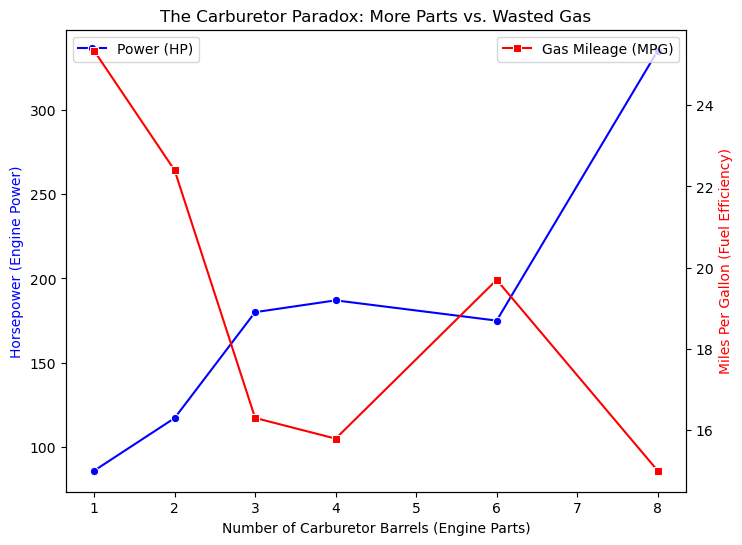

In [24]:
plt.figure(figsize=(8, 6))

# 3. Draw the Blue line: This shows how Power (Horsepower) goes up
ax1 = sns.lineplot(data=df, x='carb', y='hp', color='blue', marker='o', label='Power (HP)', errorbar=None)

# 4. Draw the Red line: This shows how Gas Mileage (MPG) goes down
# We use a second side-scale so we can see both lines clearly at once
ax2 = ax1.twinx()
sns.lineplot(data=df, x='carb', y='mpg', color='red', marker='s', label='Gas Mileage (MPG)', ax=ax2, errorbar=None)

# 5. Add a Title and label the sides so we know what is what
plt.title('The Carburetor Paradox: More Parts vs. Wasted Gas')
ax1.set_xlabel('Number of Carburetor Barrels (Engine Parts)')
ax1.set_ylabel('Horsepower (Engine Power)', color='blue')
ax2.set_ylabel('Miles Per Gallon (Fuel Efficiency)', color='red')

# 6. Show the final chart
plt.show()


##### Explanation of the line chart:
- Low Carburetor Count (1–2): These points represent the efficiency peak, averaging 25.3 to 22.4 MPG with manageable power between 86 and 117 HP.
- The Mid-Range Drop (2–4): As carburetors double from 2 to 4, the red line drops sharply from 22.4 to 15.8 MPG, marking a massive 30% loss in fuel economy.
- The Performance Ceiling (4): This is the most common high-power setup, reaching an average of 187 HP, but pushing efficiency down into the "danger zone" of 15.8 MPG.
-The Final Plateau (8): The final data point hits the absolute power peak of 335 HP, but fuel efficiency bottoms out at its lowest level of 15.0 MPG.

#### `2. 4-speed manual is the true "efficiency winner.`

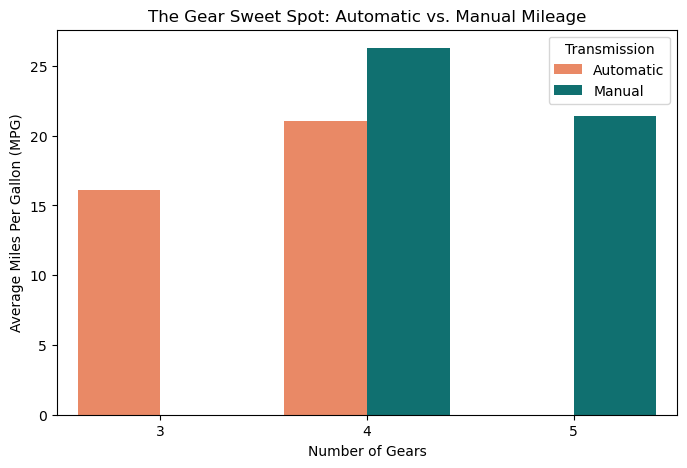

In [25]:
# Create the chart
plt.figure(figsize=(8, 5))

# Using 'hue' shows Automatic and Manual side-by-side for each gear count
sns.barplot(data=df, x='gear', y='mpg', hue='am', palette=['coral', 'teal'], errorbar=None)

# 4. Simple everyday labels
plt.title('The Gear Sweet Spot: Automatic vs. Manual Mileage')
plt.xlabel('Number of Gears')
plt.ylabel('Average Miles Per Gallon (MPG)')
plt.legend(title='Transmission')

plt.show()

##### Explanation of Bar Chart
- Manual 4-speeds are the overall efficiency winners in this dataset, averaging ~26.3 MPG.At 4 gears, the manual transmission still outperforms the automatic by over 5 MPG.
- Most automatic cars in the set only have 3 gears and sit at the bottom of the efficiency scale (~16.1 MPG).
- Manual 5-speeds actually have lower average mileage than 4-speeds because they are typically found in high-performance sports cars with larger engines.

#### `3. Lighter car has better mileage.`

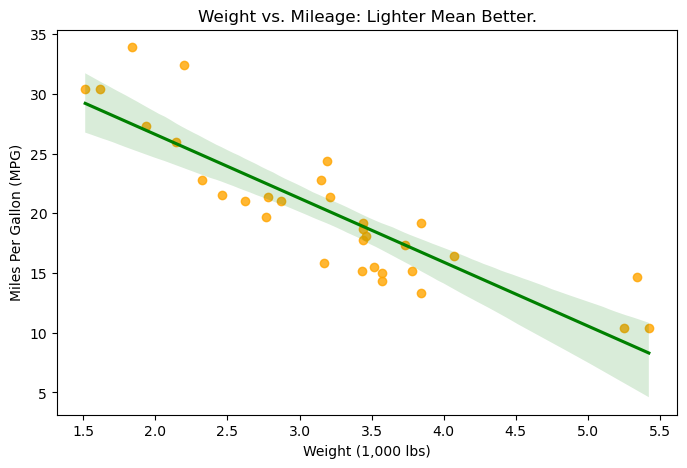

In [26]:
# Simple scatter plot with a trend line

plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='wt', y='mpg', color='orange', line_kws={'color':'green'})

plt.title('Weight vs. Mileage: Lighter Mean Better.')
plt.xlabel('Weight (1,000 lbs)')
plt.ylabel('Miles Per Gallon (MPG)')
plt.show()


##### Explanation of the scatter plot
- The Lightest (Highest MPG): The Toyota Corolla weighs only about 1,513 lbs and gets the best mileage at 33.9 MPG.
- The Heaviest (Lowest MPG): Heavy cars like the Lincoln Continental weigh over 5,400 lbs and struggle with just 10.4 MPG.
- The General Rule: For every extra 1,000 lbs of weight, you typically lose around 5 to 6 miles per gallon in this dataset. 
- In short: If you want a car that saves gas, look for the lowest weight—it is one of the single best predictors of high MPG.

#### `4. Four(4) cylinder engine has the best fuel efficiency.`

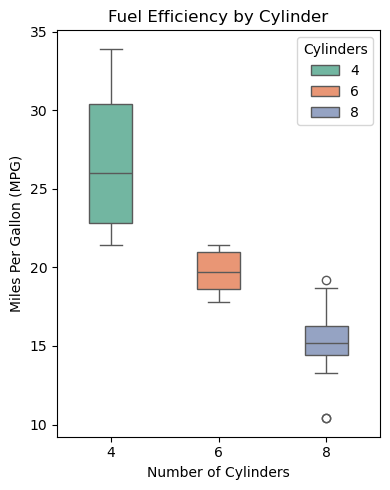

In [27]:
# Create the plot
plt.figure(figsize=(4, 5))
# showfliers=True includes individual outlier datapoints automatically
sns.boxplot(x='cyl', y='mpg', data=df, hue='cyl', palette='Set2', showfliers=True, width = 0.4)
plt.title('Fuel Efficiency by Cylinder')
plt.xlabel('Number of Cylinders')
plt.ylabel('Miles Per Gallon (MPG)')
plt.legend(title='Cylinders', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

##### Explanation of the boxplot
- The 4-cylinder box is the highest on the Y-axis, proving its superior fuel economy. Its median (~ 26 MPG) is significantly higher than the 6-cylinder (~ 19.7) and 8-cylinder (~ 15.2) groups.
- Data Distribution: The middle 50% of 4-cylinder cars (the box itself) sits entirely above the 8-cylinder range, showing a clear performance gap.
- Range (Whiskers): The top whisker of the 4-cylinder group hits 33.9 MPG (the dataset's peak), while the lowest 4-cylinder value is still more efficient than the 8-cylinder median.
- Zero Overlap: The fact that the 4-cylinder and 8-cylinder boxes do not overlap vertically confirms that cylinder count is a definitive predictor of MPG.

#### `5. High rear axle ratios(drat) secretly drive fuel efficiency beyond horsepower`

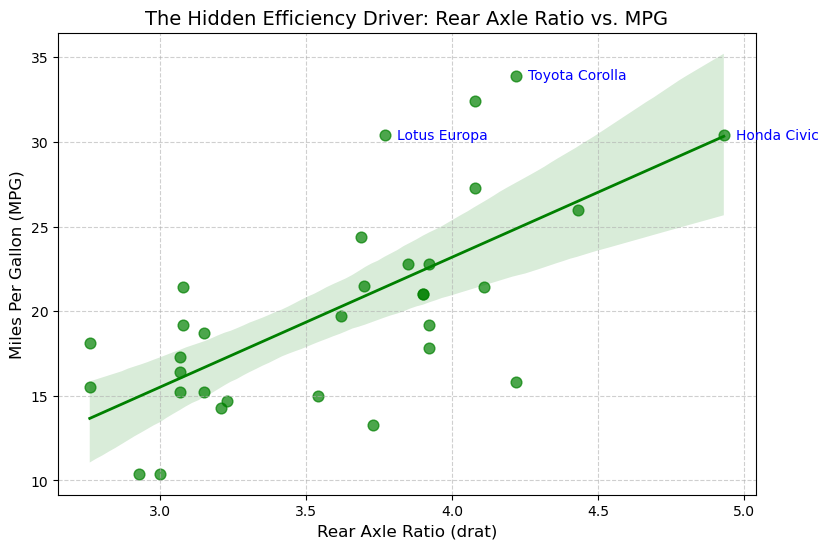

In [28]:
plt.figure(figsize=(9, 6))
# Create a scatter plot with a regression line (regplot)
#'drat' is Rear Axle Ratio, 'mpg' is Miles Per Gallon
sns.regplot(x='drat', y='mpg', data=df, 
            scatter_kws={'s': 60, 'alpha': 0.7, 'color': 'green'},  # Set point size, transparency and color
            line_kws={'color': 'green', 'lw': 2})  # Set regression line color and width

# Annotate specific high-performing models
top_performers = df.loc[['Honda Civic', 'Lotus Europa', 'Toyota Corolla']]  # Extract specific car models
for model, row in top_performers.iterrows():
    plt.text(row['drat']+0.04, row['mpg'], model, fontsize=10, color='blue', verticalalignment='center') # Add text labels next to points
# Labeling the graph
plt.title('The Hidden Efficiency Driver: Rear Axle Ratio vs. MPG', fontsize=14)  # Add descriptive title
plt.xlabel('Rear Axle Ratio (drat)', fontsize=12)  # Label x-axis
plt.ylabel('Miles Per Gallon (MPG)', fontsize=12)  # Label y-axis
plt.grid(True, linestyle='--', alpha=0.6)  # Add dashed grid lines with transparency

plt.show()

- The upward-sloping red line confirms a positive correlation. As the rear axle ratio (drat) increases, fuel efficiency consistently rises.
- The annotated models (Honda Civic, Lotus Europa, and Toyota Corolla) cluster at the top-right extreme. They demonstrate that a high ratio (above 4.0) paired with these specific designs yields peak efficiency, often exceeding 30 MPG.
- The high-ratio models sit at the top right of the graph because a higher ratio allows the engine to maintain highway speeds at lower RPMs, burning less fuel.
- Points at the bottom-left (low drat, low mpg) represent high-performance or heavier vehicles. These models require more power to get moving, which is why they sit lower on the vertical scale.
- Most data points stay relatively close to the red regression line, suggesting that drat is a very reliable predictor of mpg across this specific fleet of cars.


## `Part 6: Conclusion`

##### The ultimate takeaway from the analsis of mtccars dataset are:
- mtcars dataset proves that weight, displacement, and cylinders are the primary drivers of fuel consumption.
- While manual cars average ~24.4 MPG vs. ~17.1 MPG for automatics, this "transmission bias" exists because manuals are paired with chassis that are 1,500 lbs lighter on average.
- The "Efficiency Formula" is best seen in the Toyota Corolla, a 1.8-ton, 4-cylinder manual hitting 33.9 MPG. Conversely,
- "Efficiency Killers" like the 5-ton, 8-cylinder Lincoln Continental plummet to 10.4 MPG.
- Ultimately, the Honda Civic and Lotus Europa confirm that the recipe for peak economy is a featherweight, 4-cylinder manual gearbox configuration.